## Imports

In [1]:
import math
import json
import numpy as np
import pandas as pd
import pydantic
import time 
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
# mettre les autres imports nécessaires

## DATA 

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
...,...,...,...,...
312,162a2510d2,DUSTBIN BABY ON AT 11.30 Cannot wait x,Cannot wait,positive
313,c25871ec9e,"Not going to dwell on it. It happened, it`s p...",shame,negative
314,ddd4dd7be4,It looks like the office TV DOES get MLB Netwo...,It looks like the office TV DOES get MLB Netwo...,neutral
315,d2af698d65,Home empty handed. No comics found today. I ...,Home empty handed. No comics found today. I ...,neutral


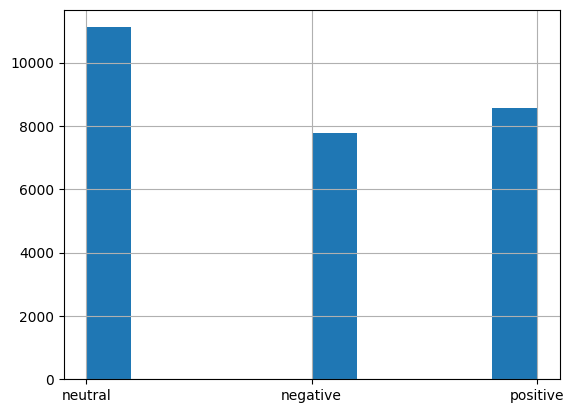

In [38]:
data=pd.read_csv('/kaggle/input/competitions/tweet-sentiment-extraction/train.csv')
data = data.drop(index=314) # line with Nan
data = data.reset_index(drop=True)
twits=data['selected_text'] # data['text']
labels=data['sentiment']
display(data.head(317))
labels.hist()

# distribution of text
lenght=pd.DataFrame([len(twits[i]) for i in range(len(twits))])

array([[<Axes: title={'center': '0'}>]], dtype=object)

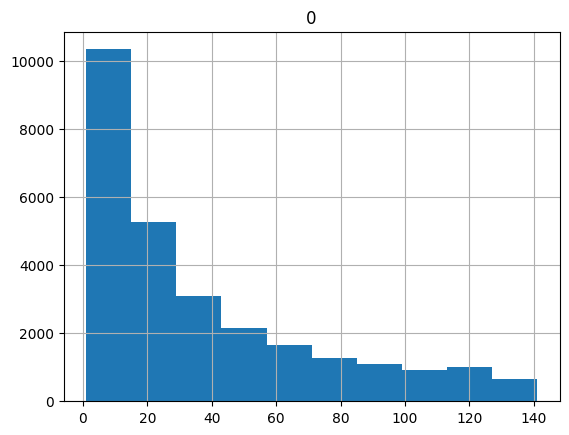

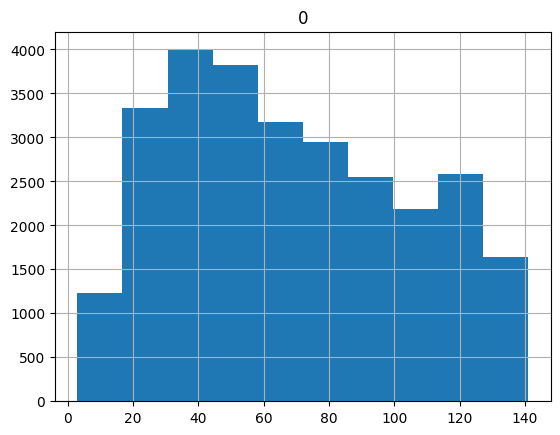

In [46]:
lenght=pd.DataFrame([len(twits[i]) for i in range(len(twits))])
lenght.hist()


big_lenght=pd.DataFrame([len(data['text'][i]) for i in range(len(data))])
big_lenght.hist()
# We take data['selected_text'] >> shorter inference, but still a few difficult cases (big lenght)

In [48]:
twits

0                      I`d have responded, if I were going
1                                                 Sooo SAD
2                                              bullying me
3                                           leave me alone
4                                            Sons of ****,
                               ...                        
27475                                               d lost
27476                                        , don`t force
27477                            Yay good for both of you.
27478                           But it was worth it  ****.
27479    All this flirting going on - The ATG smiles. Y...
Name: selected_text, Length: 27480, dtype: object

## Model
### Load (once)

In [6]:
model_id = "/kaggle/input/models/qwen-lm/qwen2.5/transformers/0.5b-instruct/1"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,   # dtype= est déprécié, utilise torch_dtype=
    device_map="cuda:0"          # force tout sur le GPU 0, évite le split inutile
)

# Warm-up (avant ta boucle ou ton premier vrai appel)
dummy = tokenizer("warm up", return_tensors="pt").input_ids.to("cuda:0")
with torch.no_grad():
    model.generate(dummy, max_new_tokens=5)
torch.cuda.synchronize()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

### Inference

In [8]:
t0=time.time()


tweet = "Just got my new iPhone and the battery dies in 2 hours. Absolute garbage."

messages = [
    {"role": "system", "content": "You are a sentiment analysis assistant. Always respond with valid JSON only."},
    {"role": "user", "content": f"""Analyze the sentiment of this tweet and return a JSON with fields: sentiment, confidence, key_phrase, reasoning.

Tweet: {tweet}

Return only the JSON, nothing else."""}
]

# Changement ici : on récupère un string d'abord, puis on tokenize séparément
text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
input_ids = tokenizer(text, return_tensors="pt").input_ids.to(model.device)

with torch.no_grad():
    output = model.generate(input_ids, max_new_tokens=150, do_sample=False)

response = tokenizer.decode(output[0][input_ids.shape[1]:], skip_special_tokens=True)
print(response)

torch.cuda.synchronize()   # ← ajoute cette ligne juste avant tf
tf=time.time()
print(tf-t0," secondes écoulées")

```json
{
  "sentiment": "negative",
  "confidence": 0.8,
  "key_phrase": "battery dies",
  "reasoning": "The user experienced an unexpected issue with their phone's battery, which they attribute to a malfunction or defect."
}
```
1.99015212059021  secondes écoulées


### Batch Inference

In [53]:
batch_of_tweets = [
    "Just got my new iPhone and the battery dies in 2 hours. Absolute garbage.",
    "Sunny day, coffee in hand, life is good.",
    "Can't believe the traffic today, been stuck for an hour.",
    "Just finished reading the best book I've ever read!",
    "The customer service was absolutely terrible, never coming back.",
    "My dog learned a new trick today, so proud!",
    "Flight delayed again, third time this month.",
    "Best pizza I've ever had, totally worth the wait.",
]

batch_of_tweets=batch_of_tweets*100

texts = [
    tokenizer.apply_chat_template([
        {"role": "system", "content": "You are a sentiment analysis assistant. Always respond with valid JSON only."},
        {"role": "user", "content": f"Analyze the sentiment of this tweet and return a JSON with fields: sentiment, confidence, key_phrase, reasoning.\nTweet: {tweet}\nReturn only the JSON, nothing else."}
    ], tokenize=False, add_generation_prompt=True)
    for tweet in batch_of_tweets
]

tokenizer.padding_side = "left"
inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to("cuda:0")

print(f"Shape des inputs : {inputs['input_ids'].shape}")  # (batch_size, seq_len)

torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=False,
    )

torch.cuda.synchronize()
tf = time.time()

# Extraction des réponses (on coupe le prompt)
input_len = inputs['input_ids'].shape[1]
responses = [
    tokenizer.decode(output[input_len:], skip_special_tokens=True)
    for output in outputs
]

for tweet, response in zip(batch_of_tweets, responses):
    print(f"\nTweet : {tweet}")
    print(f"Réponse : {response}")

print(f"\n--- {len(batch_of_tweets)} tweets en {tf - t0:.2f}s ({(tf-t0)/len(batch_of_tweets):.2f}s/tweet) ---")

Shape des inputs : torch.Size([800, 77])

Tweet : Just got my new iPhone and the battery dies in 2 hours. Absolute garbage.
Réponse : ```json
{
  "sentiment": "negative",
  "confidence": 0.9,
  "key_phrase": "battery dies",
  "reasoning": "The user mentions that their phone's battery is about to die after just two hours, which is an extremely negative experience."
}
```

Tweet : Sunny day, coffee in hand, life is good.
Réponse : ```json
{
  "sentiment": "positive",
  "confidence": 0.9,
  "key_phrase": "sunny day, coffee in hand, life is good.",
  "reasoning": "The phrase 'sunny day' suggests optimism and positivity, while 'coffee in hand' indicates enjoyment or relaxation, both contributing to an overall positive sentiment."
}
```

Tweet : Can't believe the traffic today, been stuck for an hour.
Réponse : ```json
{
  "sentiment": "negative",
  "confidence": 0.8,
  "key_phrase": "traffic",
  "reasoning": "The user expresses disappointment due to being stuck in traffic for an extended pe

# Exercice
**Structured Output with Pydantic and an LLM**

You can use the code (up ; DATA + Model) to code the requirements described in this cell. You will find a way to do below...
---

**What you built** 

A pipeline that runs a Qwen2.5-0.5B model on 27,480 real tweets, parses the LLM output, and validates it against a strict Pydantic schema:

```python
class TweetAnalysis(BaseModel):
    sentiment: Literal["positive", "negative", "neutral"]
    confidence: float = Field(ge=0.0, le=1.0)
    quotation: str = Field(max_length=40)
    reasoning: str = Field(max_length=100)
```

You measured precisely where the model fails and why — by field, by constraint type.

---

**Perspectives**

* **Regex validation on `quotation`** — a `field_validator` that checks the extracted quote is actually present in the original tweet. This is a higher level of Pydantic validation where constraints depend on external context, not just the field value itself.
* **Retry logic** — on `ValidationError`, re-prompt the LLM with the error details injected back into the prompt, up to 3 attempts. This is the pattern Instructor implements natively.
* **Failure analysis and accuracy** — build the final DataFrame with a `match` column comparing predicted vs ground truth sentiment, compute overall accuracy, and visualize the breakdown.

# Why pydantic ? 
- Efficient and automatic validation of LLM outputs against a strict schema
- Precise failure diagnosis — you know exactly which field violates which constraint, and how often

## Inference on all twits (~30 000)

In [57]:
# 45 min execution. Wait 1min for the first print :)
BATCH_SIZE = 32

def clean_response(r: str) -> str:
    r = r.strip()
    if r.startswith("```"):
        r = r.split("```")[1]
        if r.startswith("json"):
            r = r[4:]
    return r.strip()

def run_batch(batch_of_tweets):
    texts = [
        tokenizer.apply_chat_template([
            {"role": "system", "content": "You are a sentiment analysis assistant. Always respond with valid JSON only."},
            {"role": "user", "content": f"Analyze the sentiment of this tweet and return a JSON with fields: sentiment, confidence, quotation, reasoning.\nTweet: {tweet}\nReturn only the JSON, nothing else."}
        ], tokenize=False, add_generation_prompt=True)
        for tweet in batch_of_tweets
    ]
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to("cuda:0")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=200, do_sample=False)
    input_len = inputs['input_ids'].shape[1]
    return [
        tokenizer.decode(output[input_len:], skip_special_tokens=True)
        for output in outputs
    ]

tweets_list = data['text'].dropna().tolist()
labels_list = data['sentiment'].loc[data['text'].notna()].tolist()
N_TEST = len(tweets_list)
n_batches = math.ceil(N_TEST / BATCH_SIZE)

torch.cuda.synchronize()
t0 = time.time()

all_responses = []
for i in range(n_batches):
    batch = tweets_list[i * BATCH_SIZE : (i + 1) * BATCH_SIZE]
    responses = run_batch(batch)
    all_responses.extend(responses)
    if (i + 1) % 10 == 0 or (i + 1) == n_batches:
        elapsed = time.time() - t0
        rate = len(all_responses) / elapsed
        remaining = (N_TEST - len(all_responses)) / rate
        print(f"Batch {i+1}/{n_batches} — {len(all_responses)}/{N_TEST} tweets — {remaining/60:.1f} min restantes")

torch.cuda.synchronize()
tf = time.time()
total = tf - t0
print(f"\n--- {N_TEST} tweets en {total/60:.1f} min ({total/N_TEST:.2f}s/tweet) ---")

# Parsing + stats
VALID_SENTIMENTS = {"positive", "negative", "neutral"}
n_valid, n_truncated, n_bad_sentiment = 0, 0, 0
parsed_sentiments = []

for r in all_responses:
    try:
        parsed = json.loads(clean_response(r))
        sentiment = parsed.get("sentiment", "").lower()
        if sentiment not in VALID_SENTIMENTS:
            n_bad_sentiment += 1
            parsed_sentiments.append(None)
        else:
            n_valid += 1
            parsed_sentiments.append(sentiment)
    except json.JSONDecodeError:
        n_truncated += 1
        parsed_sentiments.append(None)

print(f"JSON valides + sentiment correct : {n_valid}/{N_TEST} ({100*n_valid/N_TEST:.1f}%)")
print(f"JSON tronqués/invalides          : {n_truncated}/{N_TEST}")
print(f"Sentiment hors vocabulary        : {n_bad_sentiment}/{N_TEST}")

# Accuracy sur les cas valides uniquement
results_df = pd.DataFrame({
    "tweet": tweets_list,
    "label": labels_list,
    "predicted": parsed_sentiments,
})
results_df["match"] = results_df["label"] == results_df["predicted"]
valid_df = results_df.dropna(subset=["predicted"])
print(f"\nAccuracy (sur {len(valid_df)} tweets valides) : {valid_df['match'].mean():.3f}")
print(f"Accuracy (sur {N_TEST} tweets total, None=faux) : {results_df['match'].mean():.3f}")

Batch 10/859 — 320/27480 tweets — 45.2 min restantes
Batch 20/859 — 640/27480 tweets — 45.1 min restantes
Batch 30/859 — 960/27480 tweets — 44.3 min restantes
Batch 40/859 — 1280/27480 tweets — 43.8 min restantes
Batch 50/859 — 1600/27480 tweets — 43.3 min restantes
Batch 60/859 — 1920/27480 tweets — 42.7 min restantes
Batch 70/859 — 2240/27480 tweets — 42.0 min restantes
Batch 80/859 — 2560/27480 tweets — 41.3 min restantes
Batch 90/859 — 2880/27480 tweets — 40.7 min restantes
Batch 100/859 — 3200/27480 tweets — 40.2 min restantes
Batch 110/859 — 3520/27480 tweets — 40.1 min restantes
Batch 120/859 — 3840/27480 tweets — 39.7 min restantes
Batch 130/859 — 4160/27480 tweets — 39.3 min restantes
Batch 140/859 — 4480/27480 tweets — 38.9 min restantes
Batch 150/859 — 4800/27480 tweets — 38.3 min restantes
Batch 160/859 — 5120/27480 tweets — 37.8 min restantes
Batch 170/859 — 5440/27480 tweets — 37.1 min restantes
Batch 180/859 — 5760/27480 tweets — 36.5 min restantes
Batch 190/859 — 6080/2

## Data Cleaning

In [113]:
# drop when not jsonifiable
failed_clean = []
for i, r in enumerate(all_responses):
    try:
        json.loads(clean_response(r))
    except json.JSONDecodeError:
        failed_clean.append((i, r))

print(f"{len(failed_clean)} échecs sur {len(all_responses)}")

id_failed=[failed_clean[i][0] for i in range(len(failed_clean))]
all_responses_usable=[]
for i in range(len(all_responses)):
    if i not in id_failed:
        all_responses_usable.append(all_responses[i])

print(f"{len(failed_clean)} échecs supprimés")

52 échecs sur 27480
52 échecs supprimés


In [116]:
# jsonify
all_jsons=[json.loads(clean_response(all_responses_usable[i])) for i in range(len(all_responses_usable))]


[{'sentiment': 'negative',
  'confidence': 0.8,
  'quotation': 'I would have responded, if I were going.',
  'reasoning': 'The user expresses uncertainty or reluctance to respond due to an unspecified reason.'},
 {'sentiment': 'negative',
  'confidence': 0.9,
  'quotation': 'I will miss you here in San Diego!!!',
  'reasoning': 'The tweet expresses sadness and longing for someone who is far away.'},
 {'sentiment': 'negative',
  'confidence': 0.8,
  'quotation': 'my boss is bullying me...',
  'reasoning': "The tweet expresses dissatisfaction or frustration towards one's supervisor, which is typically associated with negative emotions."}]

## Data Analysis

In [166]:
from decimal import Decimal
from typing import Annotated, Literal
from annotated_types import Gt
from pydantic import BaseModel, Field,ValidationError
import re
from collections import defaultdict


OutputStructureKind=Literal["negative","neutral","positive"]
class OutputStructureChoice(BaseModel):
    sentiment: OutputStructureKind # OK?
    confidence: float = Field(ge=0.0, le=1.0) # ge = greater and equal, le = lower and equal (ge = greater than, le = lower than : equality is excluded)
    quotation: str = Field(max_length=40)
    reasoning: str = Field(max_length=100)
    

error_counts = defaultdict(lambda: defaultdict(int))
c, d = 0, 0
N = len(all_jsons)
ALL_FIELDS = ['sentiment', 'confidence', 'quotation', 'reasoning']
ALL_TYPES = {
    'sentiment': ['literal_error', 'string_type'],
    'confidence': ['float_type', 'greater_than_equal', 'less_than_equal'],
    'quotation': ['string_type', 'string_too_long'],
    'reasoning': ['string_type', 'string_too_long'],
}

for i in range(N):
    try:
        test = all_jsons[i]
        test_pyd = OutputStructureChoice(
            sentiment=test['sentiment'],
            confidence=test['confidence'],
            quotation=test['quotation'],
            reasoning=test['reasoning']
        )
    except ValidationError as e:
        c += 1
        for error in e.errors():
            field = error['loc'][0]
            error_type = error['type']
            error_counts[field][error_type] += 1
    except:
        d += 1

print(f"ValidationError : {c} ({100*c/N:.3g}%)")
print(f"Autres erreurs  : {d} ({100*d/N:.3g}%)")
print()
for field in ALL_FIELDS:
    total_field = sum(error_counts[field].values())
    print(f"{field} — {100*total_field/N:.3g}%")
    for error_type in ALL_TYPES[field]:
        count = error_counts[field].get(error_type, 0)
        print(f"    {error_type} : {100*count/N:.3g}%")


ValidationError : 21384 (78%)
Autres erreurs  : 1 (0.00365%)

sentiment — 10.1%
    literal_error : 10.1%
    string_type : 0%
confidence — 0%
    float_type : 0%
    greater_than_equal : 0%
    less_than_equal : 0%
quotation — 36.4%
    string_type : 1.68%
    string_too_long : 34.7%
reasoning — 69.6%
    string_type : 0%
    string_too_long : 69.6%


# **Structured Output Validation with Pydantic — Key Takeaways**

The numbers here don't matter — this was a first pass with no prompt optimization, a small model, and no fine-tuning. The point was never performance.

The point is what Pydantic gives you **structurally** :

**Precise failure diagnosis.** Instead of "the model sometimes fails", you know exactly which field violates which constraint. That's the difference between debugging blind and debugging with a map.

**A clean iteration loop.** Better prompt → re-run → compare validation rates. LoRA fine-tuning → re-run → compare. Every improvement is measurable, not qualitative.

**Production-grade reliability.** Pydantic is [used by the largest companies in the world](https://docs.pydantic.dev/latest/why/) — not just for LLMs, but because it combines three things rarely found together: it saves development time through explicit contracts, it's blazing fast (core written in Rust), and its validation is strict enough to catch exactly the kind of silent errors a naive `json.loads` would miss.

What you built here manually — clean → parse → validate → retry — is the skeleton of every serious LLM output pipeline in production. Instructor, LangChain, LlamaIndex all wrap this exact pattern. Now you know what's underneath.